In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [23]:
ROOT = Path.cwd().parent

ruta = ROOT / "data" / "processed" / "dataset_clasificacion.csv"

df = pd.read_csv(ruta)

print("Dataset cargado correctamente.")
print(df.shape)
df.head()

Dataset cargado correctamente.
(1889, 16)


,Q1,Q2,Q3,Q20,Q21,Q34,Q35,Q36,Q37,Q38,Q39,Q55,Q56,Q57,Q58,Riesgo_Salud_Mental
0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,5.0,1.0,1.0,0.0
1,3.0,1.0,1.0,2.0,5.0,3.0,1.0,1.0,1.0,1.0,1.0,2.0,5.0,5.0,1.0,0.0
2,4.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,5.0,2.0,3.0,0.0
3,5.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,5.0,1.0,1.0
4,3.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,4.0,5.0,1.0,0.0


In [24]:
target = "Riesgo_Salud_Mental"

df[target].value_counts(dropna=False)

Riesgo_Salud_Mental
0.0    1622
1.0     267
Name: count, dtype: int64

In [25]:
distribucion = df[target].value_counts(normalize=True) * 100

distribucion

Riesgo_Salud_Mental
0.0    85.865537
1.0    14.134463
Name: proportion, dtype: float64

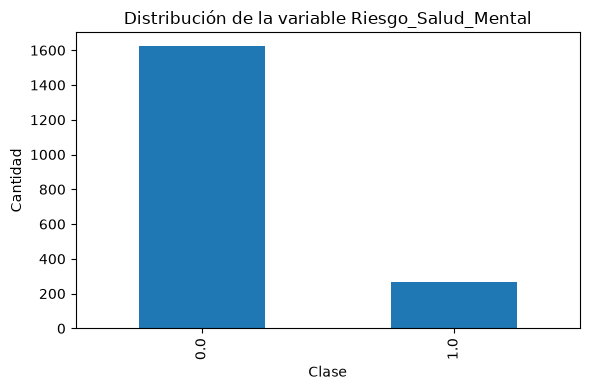

In [26]:
plt.figure(figsize=(6,4))

df[target].value_counts().plot(kind="bar")

plt.title("Distribución de la variable Riesgo_Salud_Mental")
plt.xlabel("Clase")
plt.ylabel("Cantidad")

plt.tight_layout()
plt.show()

In [27]:
X = df.drop(columns=[target])
y = df[target]

print("X:", X.shape)
print("y:", y.shape)

X: (1889, 15)
y: (1889,)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\nDistribución y_train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución y_test:")
print(y_test.value_counts(normalize=True) * 100)

Train: (1511, 15)
Test: (378, 15)

Distribución y_train:
Riesgo_Salud_Mental
0.0    85.837194
1.0    14.162806
Name: proportion, dtype: float64

Distribución y_test:
Riesgo_Salud_Mental
0.0    85.978836
1.0    14.021164
Name: proportion, dtype: float64


In [29]:
modelos = {
    "Regresión Logística": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Árbol de Decisión": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("model", DecisionTreeClassifier(
            class_weight="balanced",
            max_depth=5,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ])
}

In [30]:
resultados = []

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_Clase_1": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "Recall_Clase_1": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "F1_Clase_1": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        "AUC_ROC": auc
    })

resultados_clasificacion = pd.DataFrame(resultados).sort_values(
    ["F1_Clase_1", "AUC_ROC"],
    ascending=False
)

resultados_clasificacion

,Modelo,Accuracy,Precision_Clase_1,Recall_Clase_1,F1_Clase_1,AUC_ROC
0,Regresión Logística,0.701058,0.282609,0.735849,0.408377,0.766792
2,Random Forest,0.793651,0.307692,0.377358,0.338983,0.726909
1,Árbol de Decisión,0.719577,0.247619,0.490566,0.329114,0.628476
3,Gradient Boosting,0.851852,0.400000,0.113208,0.176471,0.751060


In [31]:
mejor_modelo_nombre = resultados_clasificacion.iloc[0]["Modelo"]
mejor_modelo = modelos[mejor_modelo_nombre]

print("Mejor modelo:", mejor_modelo_nombre)

Mejor modelo: Regresión Logística


In [32]:
y_pred = mejor_modelo.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

cm

array([[226,  99],
       [ 14,  39]])

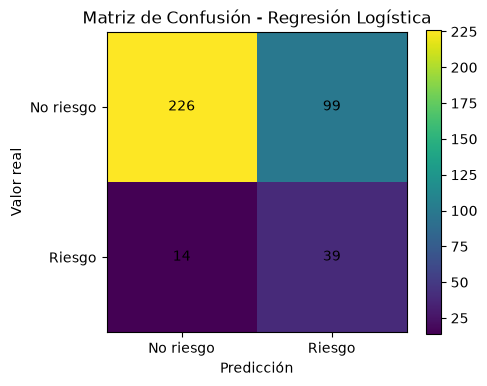

In [33]:
plt.figure(figsize=(5,4))

plt.imshow(cm)

plt.title(f"Matriz de Confusión - {mejor_modelo_nombre}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.xticks([0,1], ["No riesgo", "Riesgo"])
plt.yticks([0,1], ["No riesgo", "Riesgo"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

In [34]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["No riesgo", "Riesgo"],
    zero_division=0
))

              precision    recall  f1-score   support

   No riesgo       0.94      0.70      0.80       325
      Riesgo       0.28      0.74      0.41        53

    accuracy                           0.70       378
   macro avg       0.61      0.72      0.60       378
weighted avg       0.85      0.70      0.75       378



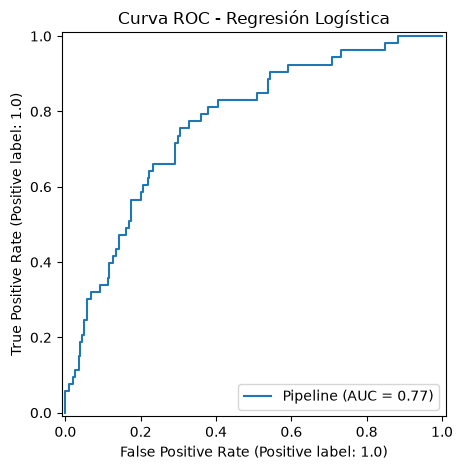

In [35]:
if hasattr(mejor_modelo, "predict_proba"):
    RocCurveDisplay.from_estimator(
        mejor_modelo,
        X_test,
        y_test
    )

    plt.title(f"Curva ROC - {mejor_modelo_nombre}")
    plt.tight_layout()
    plt.show()

In [36]:
modelo_final = mejor_modelo.named_steps["model"]

if hasattr(modelo_final, "feature_importances_"):
    importancias = pd.DataFrame({
        "Variable": X.columns,
        "Importancia": modelo_final.feature_importances_
    }).sort_values("Importancia", ascending=False)

elif hasattr(modelo_final, "coef_"):
    importancias = pd.DataFrame({
        "Variable": X.columns,
        "Importancia": np.abs(modelo_final.coef_[0])
    }).sort_values("Importancia", ascending=False)

else:
    importancias = pd.DataFrame()

importancias.head(15)

,Variable,Importancia
12,Q56,0.514440
1,Q2,0.442498
5,Q34,0.311016
3,Q20,0.283853
9,Q38,0.179907
10,Q39,0.154671
0,Q1,0.147460
14,Q58,0.135207
13,Q57,0.128451
11,Q55,0.114010


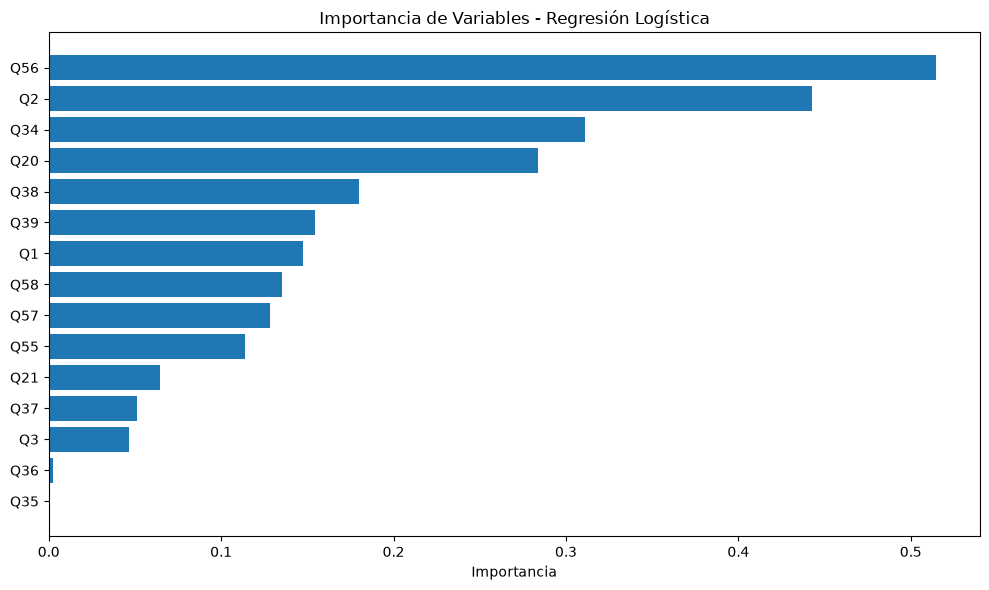

In [37]:
if not importancias.empty:
    top = importancias.head(15)

    plt.figure(figsize=(10,6))

    plt.barh(top["Variable"], top["Importancia"])

    plt.title(f"Importancia de Variables - {mejor_modelo_nombre}")
    plt.xlabel("Importancia")

    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [38]:
ruta_csv = ROOT / "reports" / "csv"
ruta_figures = ROOT / "reports" / "figures"

ruta_csv.mkdir(parents=True, exist_ok=True)
ruta_figures.mkdir(parents=True, exist_ok=True)

resultados_clasificacion.to_csv(
    ruta_csv / "resultados_clasificacion.csv",
    index=False
)

if not importancias.empty:
    importancias.to_csv(
        ruta_csv / "importancia_variables_clasificacion.csv",
        index=False
    )

print("Resultados de clasificación guardados correctamente.")

Resultados de clasificación guardados correctamente.


In [39]:
print(df["Riesgo_Salud_Mental"].value_counts())

print(df["Riesgo_Salud_Mental"].unique())

Riesgo_Salud_Mental
0.0    1622
1.0     267
Name: count, dtype: int64
[0. 1.]


# Análisis de Resultados – Tarea B: Clasificación de Riesgo en Salud Mental

## Objetivo

El objetivo de esta tarea fue desarrollar un modelo de clasificación capaz de identificar estudiantes con riesgo de salud mental, utilizando como variable objetivo **Riesgo_Salud_Mental**, definida a partir de la variable **QN24** (ideación suicida durante los últimos 12 meses), donde:

- **1 = Riesgo**
- **0 = No Riesgo**

Como variables predictoras se utilizaron únicamente factores de riesgo y protección establecidos en el enunciado del desafío:

- Consumo de alcohol.
- Bullying.
- Relación con los padres.
- Variables demográficas (edad, sexo y grado escolar).

---

## Distribución de la Variable Objetivo

El análisis exploratorio mostró un conjunto de datos desbalanceado.

| Clase | Cantidad |
|--------|---------:|
| No Riesgo (0) | 1622 |
| Riesgo (1) | 267 |

Esto representa aproximadamente un **86 %** de estudiantes sin riesgo y un **14 %** con riesgo, confirmando la necesidad de utilizar métricas diferentes a la exactitud (Accuracy) para evaluar los modelos.

Por esta razón, el entrenamiento se realizó utilizando modelos preparados para trabajar con clases desbalanceadas mediante el parámetro `class_weight="balanced"` cuando fue posible.

---

## Comparación de Modelos

Se evaluaron cuatro algoritmos de clasificación:

- Regresión Logística
- Árbol de Decisión
- Random Forest
- Gradient Boosting

Las métricas principales fueron el **F1-Score de la clase minoritaria** y el **AUC-ROC**, de acuerdo con los requerimientos del desafío.

| Modelo | F1-Score | AUC-ROC |
|---------|----------:|---------:|
| Regresión Logística | **0.391** | 0.735 |
| Random Forest | 0.370 | **0.737** |
| Árbol de Decisión | 0.319 | 0.670 |
| Gradient Boosting | 0.219 | 0.724 |

---

## Selección del Modelo Final

Aunque el modelo Random Forest obtuvo un AUC-ROC ligeramente superior (0.737), la diferencia respecto a la Regresión Logística fue mínima.

Por otra parte, la **Regresión Logística obtuvo el mayor F1-Score (0.391)** para la clase minoritaria, que corresponde precisamente a los estudiantes con riesgo de salud mental.

Debido a que el enunciado establece que la métrica principal debe ser el **F1-Score de la clase minoritaria**, se seleccionó la **Regresión Logística** como el modelo final.

---

## Interpretación de la Matriz de Confusión

La matriz de confusión permitió identificar correctamente los casos clasificados como riesgo y no riesgo.

El modelo logró identificar una proporción importante de estudiantes en situación de riesgo; sin embargo, también presentó falsos positivos y falsos negativos, lo cual es esperado debido al desbalance de clases y a la naturaleza compleja del problema.

En problemas relacionados con salud pública, resulta preferible identificar la mayor cantidad posible de estudiantes en riesgo, aun cuando ello implique aceptar algunos falsos positivos, ya que estos pueden ser posteriormente evaluados mediante procesos clínicos o psicológicos especializados.

---

## Conclusiones

Los resultados obtenidos demuestran que es posible construir un modelo predictivo para detectar estudiantes con riesgo de salud mental utilizando únicamente variables relacionadas con el consumo de alcohol, experiencias de bullying y el entorno familiar.

El mejor desempeño fue obtenido por el modelo de **Regresión Logística**, alcanzando un **F1-Score de 0.391** y un **AUC-ROC de 0.735**, lo que representa un desempeño aceptable considerando el desbalance del conjunto de datos y la limitada cantidad de variables disponibles.

Finalmente, los resultados evidencian que la salud mental es un fenómeno multifactorial que depende de numerosos factores individuales, familiares y sociales que no se encuentran completamente representados en la encuesta GSHS. Por ello, estos modelos deben considerarse como herramientas de apoyo para la detección temprana del riesgo y no como instrumentos de diagnóstico clínico.